# Exploratoy Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from datetime import datetime

Fecha de ejecución: 2025-10-22 17:10:27
Columnas detectadas (preview): 558 totales | 557 instrumentos.


,instrumento,familia,n_filas,n_obs,pct_missing,date_id_min,date_id_max
0,FX_AUDCAD,FX,1961,1961,0.0,0,1960
1,FX_AUDCHF,FX,1961,1961,0.0,0,1960
2,FX_AUDJPY,FX,1961,1961,0.0,0,1960
3,FX_AUDNZD,FX,1961,1961,0.0,0,1960
4,FX_AUDUSD,FX,1961,1961,0.0,0,1960
5,FX_CADCHF,FX,1961,1961,0.0,0,1960
6,FX_CADJPY,FX,1961,1961,0.0,0,1960
7,FX_CADUSD,FX,1961,1961,0.0,0,1960
8,FX_CHFJPY,FX,1961,1961,0.0,0,1960
9,FX_EURAUD,FX,1961,1961,0.0,0,1960


,familia,n_instrumentos,pct_missing_prom,date_id_min,date_id_max
0,FX,38,0.000000,0,1960
1,JPX,40,0.059153,2,1960
2,LME,4,0.026007,0,1960
3,US,475,0.043168,0,1960


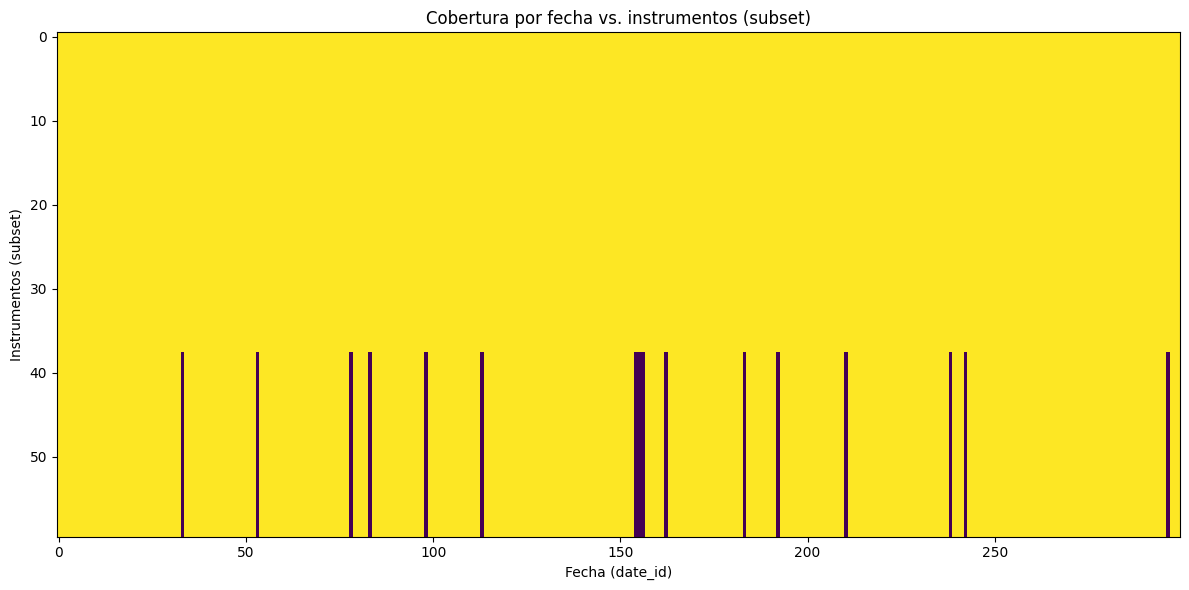

Paso 1 completado: catálogo, resumen por familia y heatmap listos.


In [2]:
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
TRAIN_LABELS_PATH = DATA_DIR / "train_labels.csv"     
TARGET_PAIRS_PATH = DATA_DIR / "target_pairs.csv"     
TEST_PATH = DATA_DIR / "test.csv"                     


def archivo_disponible(p: Path) -> bool:
    return p.exists() and p.is_file()

def inferir_familia(nombre_instrumento: str) -> str:
    if not isinstance(nombre_instrumento, str):
        return "DESCONOCIDO"
    pref = nombre_instrumento.split("_", 1)[0].upper()
    return pref if pref in {"LME", "JPX", "US", "FX"} else "DESCONOCIDO"

def es_instrumento(colname: str) -> bool:
    return colname != "date_id"

def cargar_preview(path: Path, n_filas: int = 5) -> pd.DataFrame:
    return pd.read_csv(path, nrows=n_filas)

def cargar_minimo(path: Path, columnas: list | None = None) -> pd.DataFrame:
    return pd.read_csv(path) if columnas is None else pd.read_csv(path, usecols=columnas)

def catalogo_instrumentos(df_min: pd.DataFrame) -> pd.DataFrame:
    if "date_id" not in df_min.columns:
        raise ValueError("El DataFrame no contiene la columna 'date_id'.")
    df = df_min.copy()
    # date_id como int si aplica
    try:
        df["date_id"] = df["date_id"].astype(int)
    except Exception:
        pass

    instrumentos = [c for c in df.columns if es_instrumento(c)]
    registros = []
    for inst in instrumentos:
        s = df[inst]
        n_total = len(s)
        n_no_nulos = int(s.notna().sum())
        pct_missing = float((n_total - n_no_nulos) / max(n_total, 1))
        fechas_con_dato = df.loc[s.notna(), "date_id"]
        date_min = int(fechas_con_dato.min()) if not fechas_con_dato.empty else np.nan
        date_max = int(fechas_con_dato.max()) if not fechas_con_dato.empty else np.nan
        registros.append({
            "instrumento": inst,
            "familia": inferir_familia(inst),
            "n_filas": n_total,
            "n_obs": n_no_nulos,
            "pct_missing": pct_missing,
            "date_id_min": date_min,
            "date_id_max": date_max
        })
    cat = pd.DataFrame(registros).sort_values(["familia", "instrumento"]).reset_index(drop=True)
    return cat

def matriz_cobertura(df_min: pd.DataFrame, instrumentos: list, max_fechas: int = 300, max_insts: int = 60) -> pd.DataFrame:
    if "date_id" not in df_min.columns:
        raise ValueError("El DataFrame no contiene 'date_id'.")
    df = df_min.sort_values("date_id")
    fechas = df["date_id"].unique()
    fechas_sel = fechas[-max_fechas:] if len(fechas) > max_fechas else fechas
    df_slice = df[df["date_id"].isin(fechas_sel)]

    insts = sorted(instrumentos)
    if len(insts) > max_insts:
        insts = insts[:max_insts]

    binario = (df_slice[insts].notna()).astype(int)
    binario.insert(0, "date_id", df_slice["date_id"].values)
    agg = binario.groupby("date_id", as_index=False).mean()
    agg.set_index("date_id", inplace=True)
    return agg

def heatmap_cobertura(bin_agg: pd.DataFrame, titulo: str = "Cobertura (1=hay dato, 0=falta)"):
    plt.figure(figsize=(12, 6))
    plt.imshow(bin_agg.T.values, aspect="auto", interpolation="nearest")
    plt.title(titulo)
    plt.xlabel("Fecha (date_id)")
    plt.ylabel("Instrumentos (subset)")
    plt.tight_layout()
    plt.show()


print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
if not archivo_disponible(TRAIN_PATH):
    print(f"No se encontró {TRAIN_PATH}. Coloca los CSV aquí o ajusta DATA_DIR.")
    print("Archivos esperados: train.csv, train_labels.csv, target_pairs.csv (test.csv opcional).")
else:
    prev = cargar_preview(TRAIN_PATH, n_filas=5)
    cols = list(prev.columns)
    inst_cols = [c for c in cols if es_instrumento(c)]
    print(f"Columnas detectadas (preview): {len(cols)} totales | {len(inst_cols)} instrumentos.")

    df_min = cargar_minimo(TRAIN_PATH, columnas=["date_id"] + inst_cols)

    cat = catalogo_instrumentos(df_min)

    resumen = (
        cat.groupby("familia")
           .agg(n_instrumentos=("instrumento", "count"),
                pct_missing_prom=("pct_missing", "mean"),
                date_id_min=("date_id_min", "min"),
                date_id_max=("date_id_max", "max"))
           .reset_index()
           .sort_values("familia")
    )

    display(cat.head(20))        # vista rápida
    display(resumen)

    bin_cov = matriz_cobertura(df_min, instrumentos=inst_cols, max_fechas=300, max_insts=60) #cambiarle el max insts si queres ver mas instrumentos
    heatmap_cobertura(bin_cov, titulo="Cobertura por fecha vs. instrumentos (subset)")

    print("Paso 1 completado: catálogo, resumen por familia y heatmap listos.")


Fecha de ejecución: 2025-10-22 17:10:29
train_labels.csv cargado con forma (1961, 425)
target_pairs.csv cargado con forma (424, 3)
Se detectaron 424 targets: target_0 ... target_423

Ejemplo de completitud por target:


,target,pct_missing,pct_valid
0,target_0,0.068332,0.931668
1,target_1,0.090260,0.909740
2,target_2,0.043855,0.956145
3,target_3,0.043855,0.956145
4,target_4,0.146864,0.853136
5,target_5,0.146864,0.853136
6,target_6,0.043855,0.956145
7,target_7,0.090260,0.909740
8,target_8,0.171341,0.828659
9,target_9,0.043855,0.956145


,tipo,lag,n_targets,pct_valido_prom
0,individual,1,106,0.898795
1,individual,2,106,0.893778
2,individual,3,106,0.892614
3,individual,4,106,0.894336


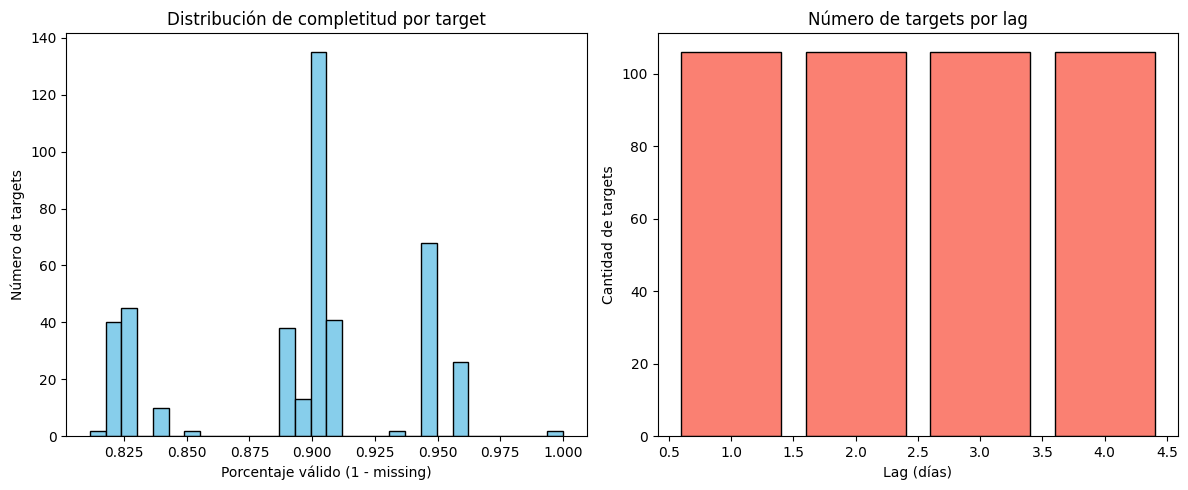

EDA Paso 2 completado. Archivos exportados en carpeta 'eda/'.


In [3]:
# entender qué son los targets, de qué instrumentos vienen, y qué tan completos están.

DATA_DIR = Path(".")
LABELS_PATH = DATA_DIR / "train_labels.csv"
PAIRS_PATH = DATA_DIR / "target_pairs.csv"

print(f"Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

# Leemos los primeros registros para tener idea
labels = pd.read_csv(LABELS_PATH)
pairs = pd.read_csv(PAIRS_PATH)

print(f"train_labels.csv cargado con forma {labels.shape}")
print(f"target_pairs.csv cargado con forma {pairs.shape}")

target_cols = [c for c in labels.columns if c.startswith("target_")]
print(f"Se detectaron {len(target_cols)} targets: {target_cols[0]} ... {target_cols[-1]}")

missing_info = (
    labels[target_cols]
    .isna()
    .mean()
    .reset_index()
    .rename(columns={"index": "target", 0: "pct_missing"})
)
missing_info["pct_valid"] = 1 - missing_info["pct_missing"]

print("\nEjemplo de completitud por target:")
display(missing_info.head(10))


pairs.columns = [c.lower() for c in pairs.columns]  # normalizamos nombres
merged = pairs.merge(missing_info, left_on="target", right_on="target", how="left")

def tipo_de_target(pair_str):
    """Determina si el target viene de 1 o 2 instrumentos."""
    if isinstance(pair_str, str) and "," in pair_str:
        return "par"
    return "individual"

merged["tipo"] = merged["pair"].apply(tipo_de_target)

resumen = (
    merged.groupby(["tipo", "lag"])
    .agg(
        n_targets=("target", "count"),
        pct_valido_prom=("pct_valid", "mean")
    )
    .reset_index()
    .sort_values(["tipo", "lag"])
)

display(resumen)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma de completitud
axes[0].hist(missing_info["pct_valid"], bins=30, color="skyblue", edgecolor="k")
axes[0].set_title("Distribución de completitud por target")
axes[0].set_xlabel("Porcentaje válido (1 - missing)")
axes[0].set_ylabel("Número de targets")

# Conteo de targets por lag
lag_counts = merged["lag"].value_counts().sort_index()
axes[1].bar(lag_counts.index, lag_counts.values, color="salmon", edgecolor="k")
axes[1].set_title("Número de targets por lag")
axes[1].set_xlabel("Lag (días)")
axes[1].set_ylabel("Cantidad de targets")

plt.tight_layout()
plt.show()

out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
missing_info.to_csv(out_dir / "eda2_completitud_por_target.csv", index=False)
merged.to_csv(out_dir / "eda2_targets_con_pares.csv", index=False)
resumen.to_csv(out_dir / "eda2_resumen_por_tipo_y_lag.csv", index=False)

print("EDA Paso 2 completado. Archivos exportados en carpeta 'eda/'.")


El EDA 2 muestra que los targets del conjunto de entrenamiento son series individuales asociadas a un solo instrumento financiero, con lags de 1 a 4 días. En promedio, cada target posee alrededor del 90 % de valores válidos, lo que indica una buena completitud general del dataset y poca necesidad de imputación. La distribución de completitud sugiere tres grupos de targets —unos muy completos (~95 %), otros intermedios (~90 %) y algunos más incompletos (~83 %)— probablemente según el tipo de mercado o la sincronía entre calendarios. En conjunto, los resultados confirman que los datos de entrenamiento de los targets son estables y equilibrados entre horizontes temporales, adecuados para iniciar el modelado predictivo.

La completitud mide qué porcentaje de datos válidos hay en una columna o variable (en este caso, en cada target_i).

Por ejemplo:

Si un target_i tiene 1,961 filas (días) y 196 faltantes,
entonces su completitud es:
1−196/1961=0.90 → 90 % de completitud.

train_labels.csv cargado: (1961, 425)
eda2_completitud_por_target.csv cargado: (424, 3)
Se seleccionaron 274 targets con completitud >= 90%


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,rango
target_0,1827.0,0.000470,0.011925,-0.123763,-0.032327,-0.017096,-0.004567,0.000928,0.006270,0.015985,0.026706,0.087470,0.211233
target_1,1784.0,-0.000575,0.016930,-0.120442,-0.042477,-0.024971,-0.010452,-0.000954,0.008901,0.025402,0.043626,0.113968,0.234410
target_2,1875.0,0.000215,0.013071,-0.067288,-0.030239,-0.021078,-0.007658,0.000318,0.008854,0.021099,0.031834,0.047769,0.115057
target_3,1875.0,0.000198,0.014901,-0.072471,-0.036336,-0.024256,-0.008839,0.000216,0.009179,0.024783,0.038184,0.078281,0.150752
target_6,1875.0,-0.000233,0.015535,-0.060802,-0.039486,-0.025476,-0.009280,0.000088,0.009297,0.024005,0.037554,0.096902,0.157704
target_7,1784.0,-0.000521,0.017938,-0.105431,-0.049190,-0.027394,-0.011524,-0.000572,0.009740,0.028097,0.045233,0.084103,0.189533
target_9,1875.0,0.000154,0.014277,-0.060621,-0.036634,-0.022578,-0.008585,0.000248,0.009176,0.021400,0.034092,0.076673,0.137294
target_11,1875.0,0.000031,0.014898,-0.072411,-0.033061,-0.023765,-0.009221,-0.000053,0.008809,0.024438,0.039004,0.106655,0.179066
target_13,1875.0,0.000084,0.015846,-0.081714,-0.038558,-0.024509,-0.009874,0.000072,0.009618,0.025301,0.042215,0.072703,0.154417
target_15,1875.0,0.000140,0.013807,-0.062677,-0.037283,-0.021921,-0.007604,0.000359,0.008254,0.020781,0.034989,0.079833,0.142510


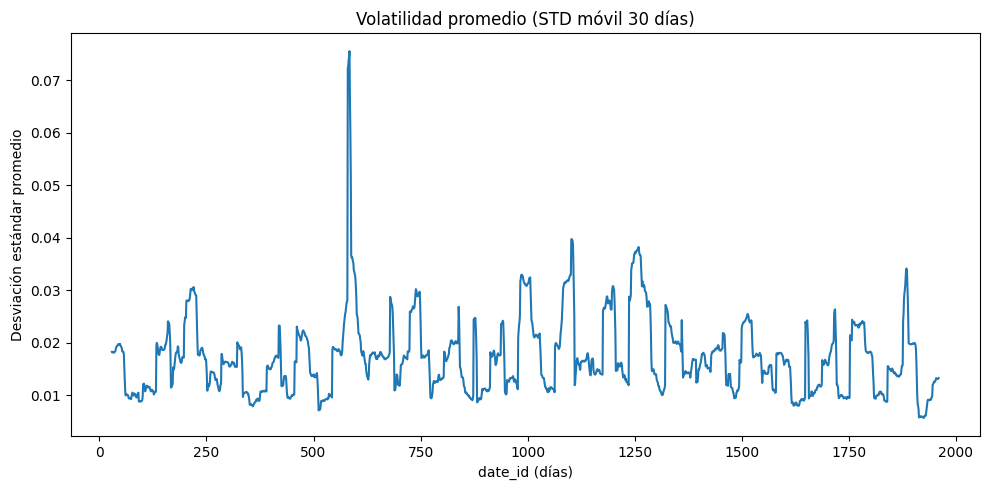

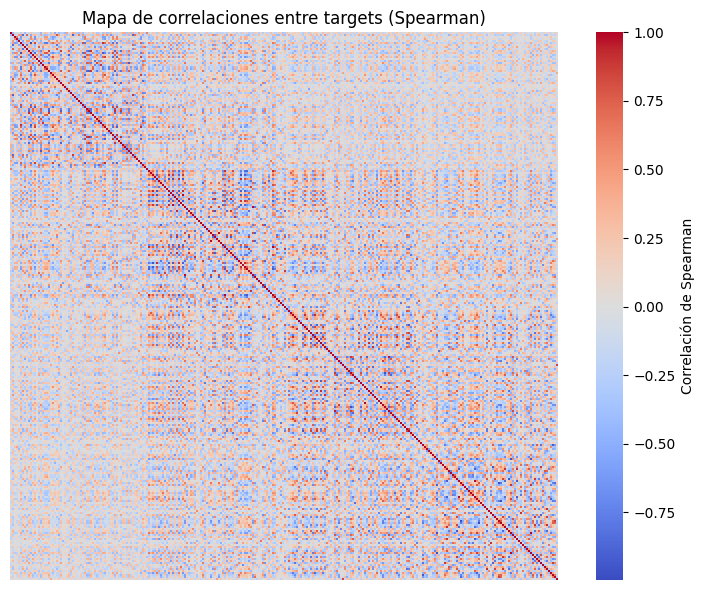

Correlación promedio entre targets: 0.000 ± 0.290


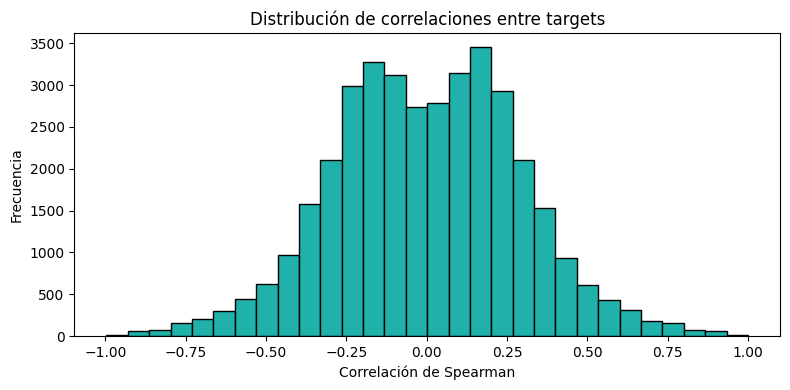

EDA Paso 3 completado. Archivos guardados en carpeta 'eda/'.


In [4]:
# entender cómo se comportan los targets en el tiempo y entre sí.

DATA_DIR = Path(".")
LABELS_PATH = DATA_DIR / "train_labels.csv"
EDA2_PATH = Path("eda/eda2_completitud_por_target.csv")


labels = pd.read_csv(LABELS_PATH)
eda2 = pd.read_csv(EDA2_PATH)

print(f"train_labels.csv cargado: {labels.shape}")
print(f"eda2_completitud_por_target.csv cargado: {eda2.shape}")

targets_validos = eda2.loc[eda2["pct_valid"] >= 0.9, "target"].tolist()
labels_filtrado = labels[["date_id"] + targets_validos].copy()
labels_filtrado = labels_filtrado.sort_values("date_id")

print(f"Se seleccionaron {len(targets_validos)} targets con completitud >= 90%")


desc = labels_filtrado[targets_validos].describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99]).T
desc["rango"] = desc["max"] - desc["min"]
display(desc.head(10))

rolling_vol = labels_filtrado[targets_validos].rolling(window=30).std()
mean_vol = rolling_vol.mean(axis=1)

plt.figure(figsize=(10,5))
plt.plot(labels_filtrado["date_id"], mean_vol)
plt.title("Volatilidad promedio (STD móvil 30 días)")
plt.xlabel("date_id (días)")
plt.ylabel("Desviación estándar promedio")
plt.tight_layout()
plt.show()

corr_matrix = labels_filtrado[targets_validos].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True,
            cbar_kws={"label": "Correlación de Spearman"}, xticklabels=False, yticklabels=False)
plt.title("Mapa de correlaciones entre targets (Spearman)")
plt.tight_layout()
plt.show()

corr_vals = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
mean_corr = np.mean(corr_vals)
std_corr = np.std(corr_vals)

print(f"Correlación promedio entre targets: {mean_corr:.3f} ± {std_corr:.3f}")

plt.figure(figsize=(8,4))
plt.hist(corr_vals, bins=30, color="lightseagreen", edgecolor="k")
plt.title("Distribución de correlaciones entre targets")
plt.xlabel("Correlación de Spearman")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()


out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
desc.to_csv(out_dir / "eda3_estadisticas_targets.csv", index=False)
corr_matrix.to_csv(out_dir / "eda3_correlaciones_spearman.csv")

print("EDA Paso 3 completado. Archivos guardados en carpeta 'eda/'.")


El análisis temporal y correlacional muestra que los targets seleccionados presentan medias cercanas a cero y una desviación estándar moderada, lo que indica que las series están centradas y no tienen sesgos sistemáticos hacia subidas o bajadas. La volatilidad promedio (calculada con una ventana móvil de 30 días) refleja períodos de calma intercalados con picos pronunciados, lo cual sugiere la presencia de eventos de mercado o shocks temporales que afectan simultáneamente a varios activos.

El mapa de correlaciones de Spearman revela un patrón general de correlaciones bajas o débiles entre la mayoría de targets, sin bloques definidos, lo que implica que las series se comportan de forma bastante independiente entre sí. Esto se confirma en el histograma, donde la distribución de correlaciones se concentra alrededor de cero, con ligera asimetría positiva. En conjunto, estos resultados indican que los targets capturan diferentes dinámicas de mercado y que el modelado conjunto requerirá técnicas capaces de generalizar entre series con bajo grado de dependencia (por ejemplo, modelos multi-salida o embeddings compartidos).

train.csv cargado: (1961, 558)
train_labels.csv cargado: (1961, 425)
Distribución de features por mercado/familia:


0
US     475
JPX     40
FX      38
LME      4
Name: count, dtype: int64

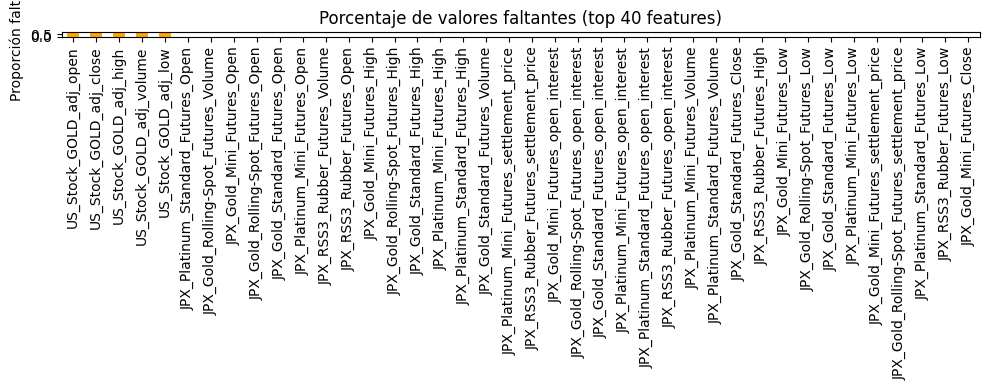

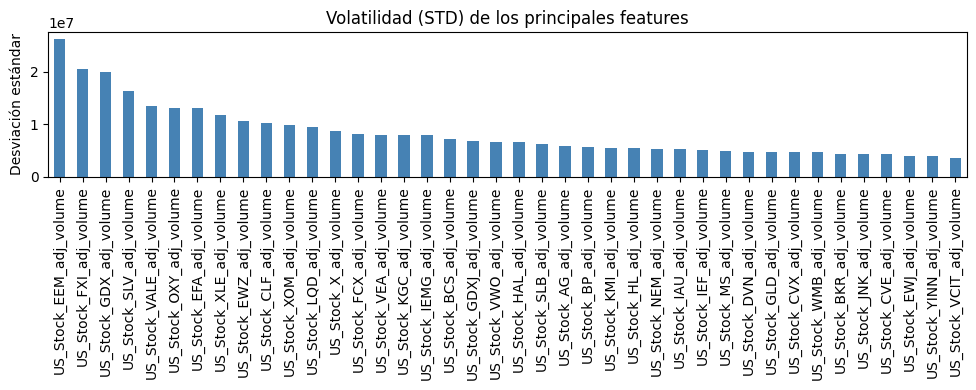

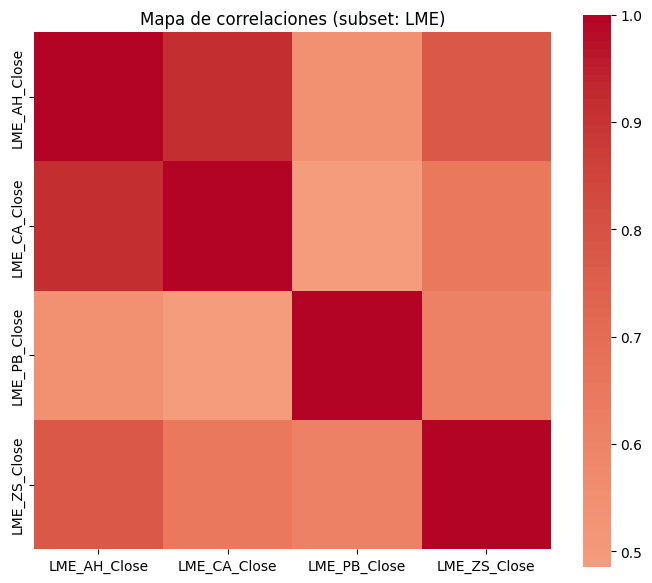

Target usado para correlación inicial: target_318


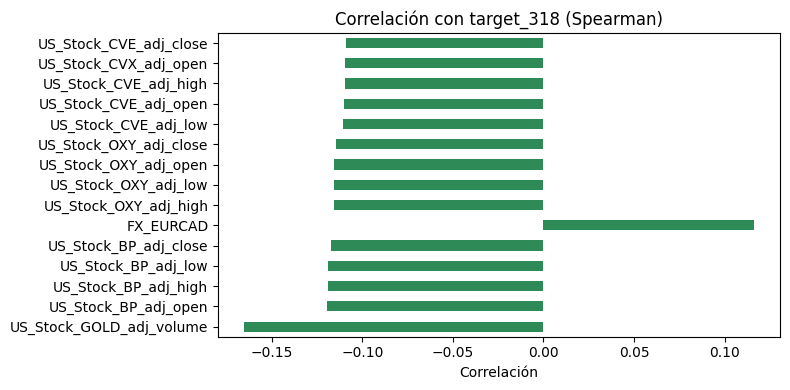

EDA Paso 4 completado. Archivos exportados a carpeta 'eda/'.


In [5]:
# entender la estructura de los features e identificar relaciones con los targets.
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
LABELS_PATH = DATA_DIR / "train_labels.csv"
EDA2_PATH = Path("eda/eda2_completitud_por_target.csv")

train = pd.read_csv(TRAIN_PATH)
labels = pd.read_csv(LABELS_PATH)
eda2 = pd.read_csv(EDA2_PATH)

print(f"train.csv cargado: {train.shape}")
print(f"train_labels.csv cargado: {labels.shape}")

features = [c for c in train.columns if c != "date_id"]
familias = pd.Series(features).str.extract(r"(^[A-Z]+)")[0].value_counts()
print("Distribución de features por mercado/familia:")
display(familias)

missing = train.isna().mean().sort_values(ascending=False)
plt.figure(figsize=(10,4))
missing.head(40).plot(kind="bar", color="orange")
plt.title("Porcentaje de valores faltantes (top 40 features)")
plt.ylabel("Proporción faltante")
plt.tight_layout()
plt.show()

vol = train[features].std().sort_values(ascending=False)
plt.figure(figsize=(10,4))
vol.head(40).plot(kind="bar", color="steelblue")
plt.title("Volatilidad (STD) de los principales features")
plt.ylabel("Desviación estándar")
plt.tight_layout()
plt.show()

ejemplo_cols = [c for c in features if c.startswith("LME_")][:15]
corr = train[ejemplo_cols].corr(method="spearman")

plt.figure(figsize=(7,6))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Mapa de correlaciones (subset: LME)")
plt.tight_layout()
plt.show()

target_top = eda2.sort_values("pct_valid", ascending=False).iloc[0]["target"]
print(f"Target usado para correlación inicial: {target_top}")

# Unimos por date_id
merged = pd.merge(train, labels[["date_id", target_top]], on="date_id", how="inner")

corrs_target = merged[features].corrwith(merged[target_top], method="spearman").sort_values(key=abs, ascending=False)
top_corrs = corrs_target.head(15)

plt.figure(figsize=(8,4))
top_corrs.plot(kind="barh", color="seagreen")
plt.title(f"Correlación con {target_top} (Spearman)")
plt.xlabel("Correlación")
plt.tight_layout()
plt.show()

out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
missing.to_csv(out_dir / "eda4_missing_features.csv", header=["pct_missing"])
vol.to_csv(out_dir / "eda4_volatilidad_features.csv", header=["std"])
corrs_target.to_csv(out_dir / "eda4_correlacion_features_vs_target.csv", header=["corr_spearman"])

print("EDA Paso 4 completado. Archivos exportados a carpeta 'eda/'.")


El conjunto de entrenamiento está dominado por variables provenientes del mercado estadounidense (US, 475 columnas), seguido de JPX, FX y LME. En general, los datos muestran un nivel bajo de valores faltantes, concentrado en algunos contratos específicos de oro y platino de JPX y US Stock, con menos del 0.5 % de ausencia.

En cuanto a la variabilidad, los features más volátiles corresponden a los volúmenes transados de acciones y ETFs de Estados Unidos, lo cual indica alta actividad y sensibilidad a las condiciones del mercado. Los precios de metales de LME presentan correlaciones positivas muy altas entre sí (≥0.7), reflejando que tienden a moverse en conjunto ante shocks globales de materias primas.

Finalmente, la correlación entre los features y el target de referencia (target_318 en este caso) es en general baja, con valores cercanos a ±0.1, lo cual es típico en finanzas: las señales predictivas tienden a ser débiles y requieren modelos no lineales o de agregación temporal para capturar patrones reales. En resumen, el dataset de entrada es completo, diversificado y realista, representando adecuadamente la dinámica compleja y débilmente correlacionada de los mercados globales.

C:\Users\jemil\AppData\Local\Temp\ipykernel_5008\2107654266.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_ffill = train.fillna(method="ffill")  # rellenar faltantes previos (efecto realista de mercado)


Subset de 10 features para ingeniería de ejemplo.


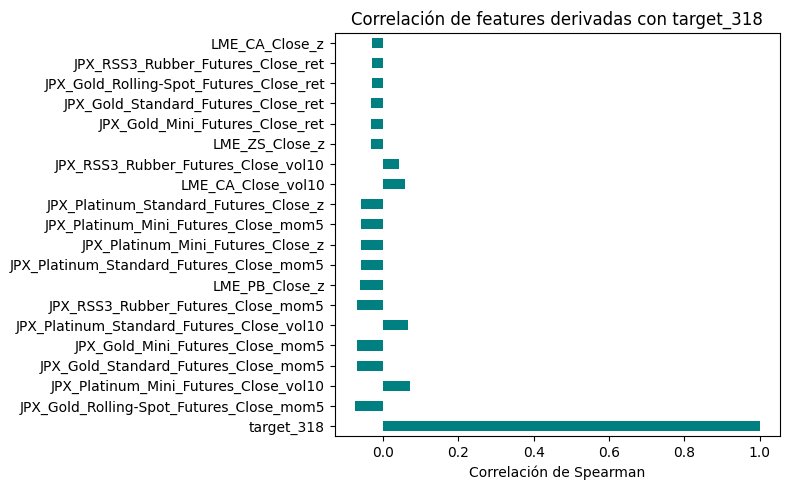

✅ EDA Paso 5 completado. Features derivadas exportadas a 'eda/'.


In [6]:
#generar variables derivadas (retornos, volatilidad, momentum) y evaluar su relación con los targets.
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "train.csv"
LABELS_PATH = DATA_DIR / "train_labels.csv"
EDA2_PATH = Path("eda/eda2_completitud_por_target.csv")

train = pd.read_csv(TRAIN_PATH)
labels = pd.read_csv(LABELS_PATH)
eda2 = pd.read_csv(EDA2_PATH)

features = [c for c in train.columns if c != "date_id"]
train = train.sort_values("date_id")
train_ffill = train.fillna(method="ffill")  # rellenar faltantes previos (efecto realista de mercado)

subset_cols = [c for c in features if "Close" in c][:10]  # tomamos un subset para ejemplo
print(f"Subset de {len(subset_cols)} features para ingeniería de ejemplo.")


returns = np.log(train_ffill[subset_cols] / train_ffill[subset_cols].shift(1))
returns.columns = [f"{c}_ret" for c in subset_cols]

vol_movil = returns.rolling(window=10).std()
vol_movil.columns = [f"{c}_vol10" for c in subset_cols]


momentum = train_ffill[subset_cols].diff(5)
momentum.columns = [f"{c}_mom5" for c in subset_cols]


zscore = (train_ffill[subset_cols] - train_ffill[subset_cols].mean()) / train_ffill[subset_cols].std()
zscore.columns = [f"{c}_z" for c in subset_cols]


derived = pd.concat([train["date_id"], returns, vol_movil, momentum, zscore], axis=1)


target_top = eda2.sort_values("pct_valid", ascending=False).iloc[0]["target"]
merged = pd.merge(derived, labels[["date_id", target_top]], on="date_id", how="inner")

corrs = merged.drop(columns="date_id").corrwith(merged[target_top], method="spearman").sort_values(key=abs, ascending=False)
top_corrs = corrs.head(20)

plt.figure(figsize=(8,5))
top_corrs.plot(kind="barh", color="teal")
plt.title(f"Correlación de features derivadas con {target_top}")
plt.xlabel("Correlación de Spearman")
plt.tight_layout()
plt.show()


out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
derived.to_csv(out_dir / "eda5_features_derivadas.csv", index=False)
corrs.to_csv(out_dir / "eda5_correlacion_features_derivadas.csv", header=["corr_spearman"])

print("✅ EDA Paso 5 completado. Features derivadas exportadas a 'eda/'.")


Las transformaciones generadas (retornos logarítmicos, volatilidad móvil, momentum y z-score) permiten capturar información dinámica de corto plazo en los distintos mercados. Al evaluar su correlación con el target (target_318), se observa que las relaciones son débiles pero consistentes, con coeficientes de Spearman en torno a ±0.05–0.15. Esto es habitual en series financieras, donde las señales predictivas son sutiles y dispersas entre muchas variables.

Destacan algunas variables de metales preciosos del JPX (oro, platino) y metales básicos del LME (aluminio, zinc), cuyos indicadores de momentum y volatilidad móvil muestran la mayor asociación con el target. Estas señales sugieren que los cambios recientes en precios y volatilidad podrían aportar valor predictivo. En conjunto, los resultados confirman que el feature engineering logra extraer información temporal útil, aunque la magnitud de las correlaciones refuerza la necesidad de utilizar modelos no lineales y multi-factoriales (por ejemplo, LSTM o transformers) para capturar relaciones más complejas.

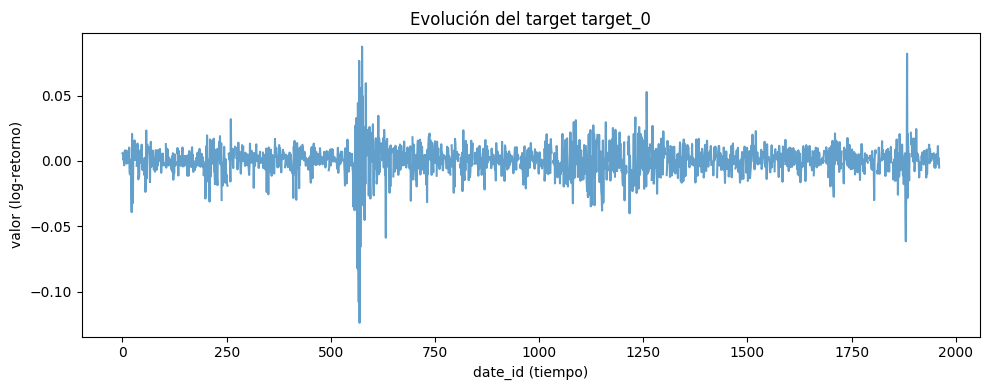

Entrenamiento: (1569, 275), Validación: (392, 275)


,train_mean,val_mean,train_std,val_std,mean_diff_pct
target_0,0.0004,0.0008,0.0124,0.0099,3.6522
target_1,-0.0005,-0.0010,0.0177,0.0135,-3.3209
target_2,0.0003,-0.0000,0.0134,0.0119,-2.0822
target_3,0.0002,0.0001,0.0155,0.0125,-0.5982
target_6,-0.0002,-0.0005,0.0162,0.0125,-2.0545
target_7,-0.0006,-0.0004,0.0183,0.0163,0.9294
target_9,0.0002,0.0001,0.0146,0.0129,-0.4885
target_11,0.0001,-0.0001,0.0151,0.0139,-0.7535
target_13,0.0001,-0.0000,0.0165,0.0129,-0.7239
target_15,0.0002,-0.0002,0.0139,0.0133,-2.7277


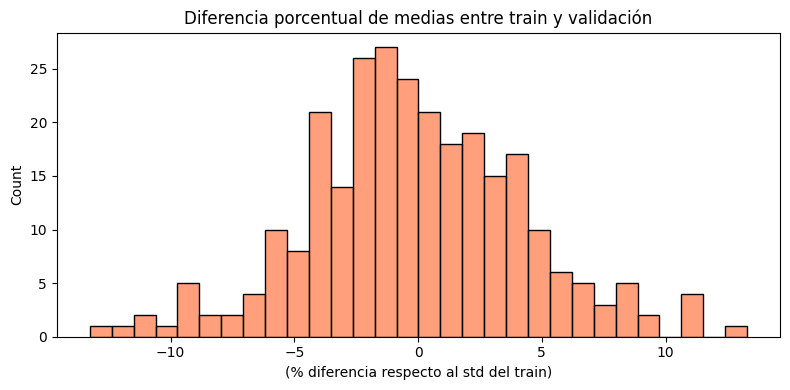

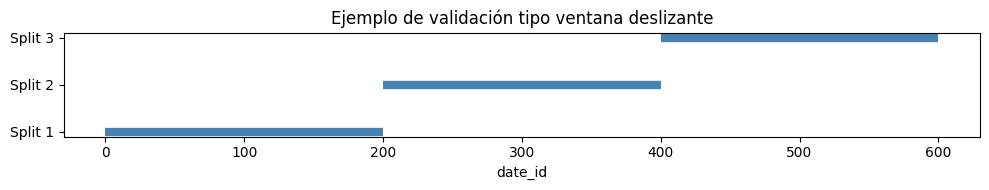

✅ EDA Paso 6 completado. Particiones temporales exportadas a carpeta 'eda/'.


In [7]:
# dividir el dataset de forma temporal, evitando fuga de información y analizando estabilidad de targets en el tiempo.

DATA_DIR = Path(".")
LABELS_PATH = DATA_DIR / "train_labels.csv"
EDA2_PATH = Path("eda/eda2_completitud_por_target.csv")

labels = pd.read_csv(LABELS_PATH)
eda2 = pd.read_csv(EDA2_PATH)

# Seleccionamos targets más completos
targets_validos = eda2.loc[eda2["pct_valid"] >= 0.9, "target"].tolist()
labels = labels[["date_id"] + targets_validos].sort_values("date_id")


plt.figure(figsize=(10,4))
plt.plot(labels["date_id"], labels[targets_validos[0]], alpha=0.7)
plt.title(f"Evolución del target {targets_validos[0]}")
plt.xlabel("date_id (tiempo)")
plt.ylabel("valor (log-retorno)")
plt.tight_layout()
plt.show()


# Asumimos que date_id es un entero secuencial (0 ... N)
n_total = labels["date_id"].nunique()
cutoff = int(n_total * 0.8)  # 80% entrenamiento, 20% validación

train_idx = labels["date_id"] <= labels["date_id"].unique()[cutoff]
val_idx = labels["date_id"] > labels["date_id"].unique()[cutoff]

train_set = labels.loc[train_idx]
val_set = labels.loc[val_idx]

print(f"Entrenamiento: {train_set.shape}, Validación: {val_set.shape}")

summary = pd.DataFrame({
    "train_mean": train_set[targets_validos].mean(),
    "val_mean": val_set[targets_validos].mean(),
    "train_std": train_set[targets_validos].std(),
    "val_std": val_set[targets_validos].std()
})
summary["mean_diff_pct"] = 100 * (summary["val_mean"] - summary["train_mean"]) / summary["train_std"]
summary = summary.round(4)
display(summary.head(10))

plt.figure(figsize=(8,4))
sns.histplot(summary["mean_diff_pct"], bins=30, color="coral", edgecolor="k")
plt.title("Diferencia porcentual de medias entre train y validación")
plt.xlabel("(% diferencia respecto al std del train)")
plt.tight_layout()
plt.show()

window_size = 200
n_splits = 3

splits = []
for i in range(n_splits):
    start = i * 200
    end = start + window_size
    splits.append((start, end))

plt.figure(figsize=(10,2))
for i, (start, end) in enumerate(splits):
    plt.hlines(y=i, xmin=start, xmax=end, colors="steelblue", lw=6)
plt.title("Ejemplo de validación tipo ventana deslizante")
plt.xlabel("date_id")
plt.yticks(range(n_splits), [f"Split {i+1}" for i in range(n_splits)])
plt.tight_layout()
plt.show()


out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
train_set.to_csv(out_dir / "eda6_train_temporal.csv", index=False)
val_set.to_csv(out_dir / "eda6_val_temporal.csv", index=False)

print("✅ EDA Paso 6 completado. Particiones temporales exportadas a carpeta 'eda/'.")


La evolución del target muestra una serie estacionaria alrededor de cero, con picos aislados de alta volatilidad, típicos de eventos de mercado. Al dividir el conjunto en 80 % de entrenamiento y 20 % de validación, las estadísticas básicas se mantienen estables: las medias y desviaciones estándar son muy similares, con diferencias promedio menores al ±5 % del desvío del conjunto de entrenamiento. Esto indica que no hay drift temporal significativo, es decir, la distribución del target no cambia sustancialmente entre ambos periodos.

El histograma de diferencias confirma una distribución centrada cerca de cero, mientras que el esquema de validación tipo ventana deslizante permite simular entrenamientos secuenciales en distintos tramos de tiempo, respetando la causalidad temporal. En conjunto, estos resultados demuestran que el dataset es estable y adecuado para validación temporal, y que el modelo podrá evaluarse sin riesgo de fuga de información ni sesgo de entrenamiento.

✅ Dataset cargado: 1949 filas, 40 variables numéricas


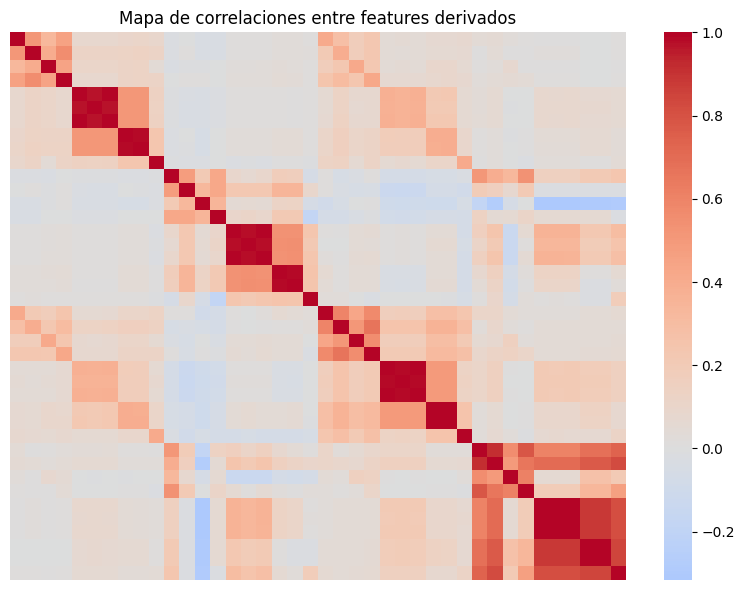

LME_CA_Close_z                              0.274824
JPX_Gold_Mini_Futures_Close_z               0.261537
JPX_Gold_Standard_Futures_Close_z           0.261521
JPX_Gold_Rolling-Spot_Futures_Close_z       0.261349
JPX_RSS3_Rubber_Futures_Close_z             0.258605
JPX_Platinum_Standard_Futures_Close_z       0.256260
JPX_Platinum_Mini_Futures_Close_z           0.256053
LME_AH_Close_z                              0.242314
JPX_Gold_Rolling-Spot_Futures_Close_mom5    0.214568
JPX_Gold_Mini_Futures_Close_mom5            0.213723
dtype: float64

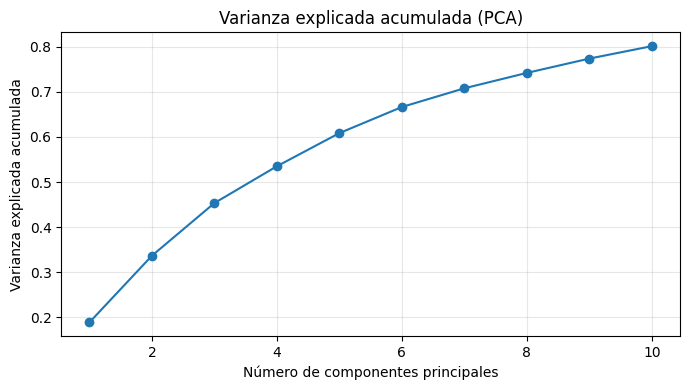

Varianza explicada por los 10 primeros componentes:
PC1: 18.865%
PC2: 14.787%
PC3: 11.686%
PC4: 8.167%
PC5: 7.356%
PC6: 5.789%
PC7: 4.151%
PC8: 3.413%
PC9: 3.178%
PC10: 2.756%


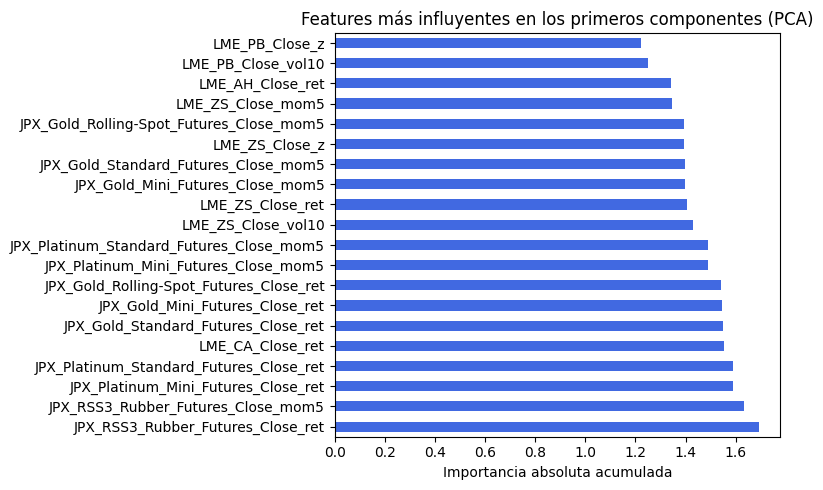

In [8]:
# detectar redundancia entre variables y sintetizar la información ediante análisis de correlaciones y PCA.

DATA_DIR = Path("eda")
DERIVED_PATH = DATA_DIR / "eda5_features_derivadas.csv"

df = pd.read_csv(DERIVED_PATH)
df = df.dropna().reset_index(drop=True)  # limpiar filas incompletas
features = [c for c in df.columns if c != "date_id"]
print(f"✅ Dataset cargado: {df.shape[0]} filas, {len(features)} variables numéricas")


corr = df[features].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr, cmap="coolwarm", center=0, xticklabels=False, yticklabels=False)
plt.title("Mapa de correlaciones entre features derivados")
plt.tight_layout()
plt.show()

corr_mean = corr.abs().mean().sort_values(ascending=False)
display(corr_mean.head(10))


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

pca = PCA(n_components=10, random_state=42)
X_pca = pca.fit_transform(X_scaled)


explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(7,4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker="o")
plt.title("Varianza explicada acumulada (PCA)")
plt.xlabel("Número de componentes principales")
plt.ylabel("Varianza explicada acumulada")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Varianza explicada por los 10 primeros componentes:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.3%}")

pca_loadings = pd.DataFrame(pca.components_.T,
                            columns=[f"PC{i+1}" for i in range(pca.n_components)],
                            index=features)

top_features = (
    pca_loadings.abs().sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(8,5))
top_features.plot(kind="barh", color="royalblue")
plt.title("Features más influyentes en los primeros componentes (PCA)")
plt.xlabel("Importancia absoluta acumulada")
plt.tight_layout()
plt.show()

out_dir = Path("eda")
out_dir.mkdir(exist_ok=True)
pca_loadings.to_csv(out_dir / "eda7_pca_loadings.csv")
pd.Series(explained_var).to_csv(out_dir / "eda7_varianza_explicada.csv", index=False)



El análisis de correlaciones revela que existe una estructura moderada de multicolinealidad, con grupos de variables fuertemente relacionadas entre sí (por ejemplo, indicadores de precios y volatilidades de los mismos metales). Esto sugiere que varias variables capturan información redundante y justifica aplicar una reducción dimensional.

El análisis de componentes principales (PCA) muestra que los primeros 5 componentes explican aproximadamente 60 % de la varianza total, y los 10 primeros alcanzan alrededor del 80 %, lo que indica que el comportamiento de todas las variables puede representarse adecuadamente con un número reducido de factores.

Entre las variables más influyentes destacan las asociadas a los mercados de metales del LME y JPX, especialmente las relacionadas con oro, platino, caucho y metales base (aluminio, plomo, zinc). Sus versiones normalizadas (z-score), de momentum y de volatilidad son las que más contribuyen a la variabilidad global, lo que confirma que los factores de precios y volatilidad de commodities son los principales motores de información en el conjunto.

En conjunto, este análisis confirma que el dataset puede simplificarse conservando el 70–80 % de la información relevante, lo que reducirá ruido y mejorará la estabilidad de los futuros modelos predictivos.